In [1]:
# Import libraries
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

In [2]:
# Import data
df = pd.read_csv('data.csv', parse_dates = ['date'])
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


# Exploratory Data Analysis (EDA) Steps

In [3]:
# Check the information about each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[ns]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  street         4600 non-null   object        
 15  city           4600 n

In [4]:
# Check summary statistics of numerical columns
df_summary_stat = df.describe()
df_summary_stat

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4600,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,2014-06-07 03:14:42.782608640,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
min,2014-05-02 00:00:00,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,2014-05-21 00:00:00,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,2014-06-09 00:00:00,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,2014-06-24 00:00:00,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2014-07-10 00:00:00,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000
std,NaN,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536


In [5]:
# Check the bedroom, bathroom and price columns for further investigation of the 0s observed
print(df[df['bedrooms'] == 0])
print(df[df['bathrooms'] == 0])
len(df[df['price'] == 0])

           date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
2365 2014-06-12  1095000.0       0.0        0.0         3064      4764   
3209 2014-06-24  1295648.0       0.0        0.0         4810     28008   

      floors  waterfront  view  condition  sqft_above  sqft_basement  \
2365     3.5           0     2          3        3064              0   
3209     2.0           0     0          3        4810              0   

      yr_built  yr_renovated            street     city  statezip country  
2365      1990          2009     814 E Howe St  Seattle  WA 98102     USA  
3209      1990          2009  20418 NE 64th Pl  Redmond  WA 98053     USA  
           date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
2365 2014-06-12  1095000.0       0.0        0.0         3064      4764   
3209 2014-06-24  1295648.0       0.0        0.0         4810     28008   

      floors  waterfront  view  condition  sqft_above  sqft_basement  \
2365     3.5           0     2       

49

In [6]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
# Check the city column to ensure there are no typographical errors or inconsistencies
df['city'].unique()

array(['Shoreline', 'Seattle', 'Kent', 'Bellevue', 'Redmond',
       'Maple Valley', 'North Bend', 'Lake Forest Park', 'Sammamish',
       'Auburn', 'Des Moines', 'Bothell', 'Federal Way', 'Kirkland',
       'Issaquah', 'Woodinville', 'Normandy Park', 'Fall City', 'Renton',
       'Carnation', 'Snoqualmie', 'Duvall', 'Burien', 'Covington',
       'Inglewood-Finn Hill', 'Kenmore', 'Newcastle', 'Mercer Island',
       'Black Diamond', 'Ravensdale', 'Clyde Hill', 'Algona', 'Skykomish',
       'Tukwila', 'Vashon', 'Yarrow Point', 'SeaTac', 'Medina',
       'Enumclaw', 'Snoqualmie Pass', 'Pacific', 'Beaux Arts Village',
       'Preston', 'Milton'], dtype=object)

In [8]:
# Check the number of times each city occur
df['city'].value_counts()

city
Seattle                1573
Renton                  293
Bellevue                286
Redmond                 235
Issaquah                187
Kirkland                187
Kent                    185
Auburn                  176
Sammamish               175
Federal Way             148
Shoreline               123
Woodinville             115
Maple Valley             96
Mercer Island            86
Burien                   74
Snoqualmie               71
Kenmore                  66
Des Moines               58
North Bend               50
Covington                43
Duvall                   42
Lake Forest Park         36
Bothell                  33
Newcastle                33
SeaTac                   29
Tukwila                  29
Vashon                   29
Enumclaw                 28
Carnation                22
Normandy Park            18
Clyde Hill               11
Medina                   11
Fall City                11
Black Diamond             9
Ravensdale                7
Pacific        

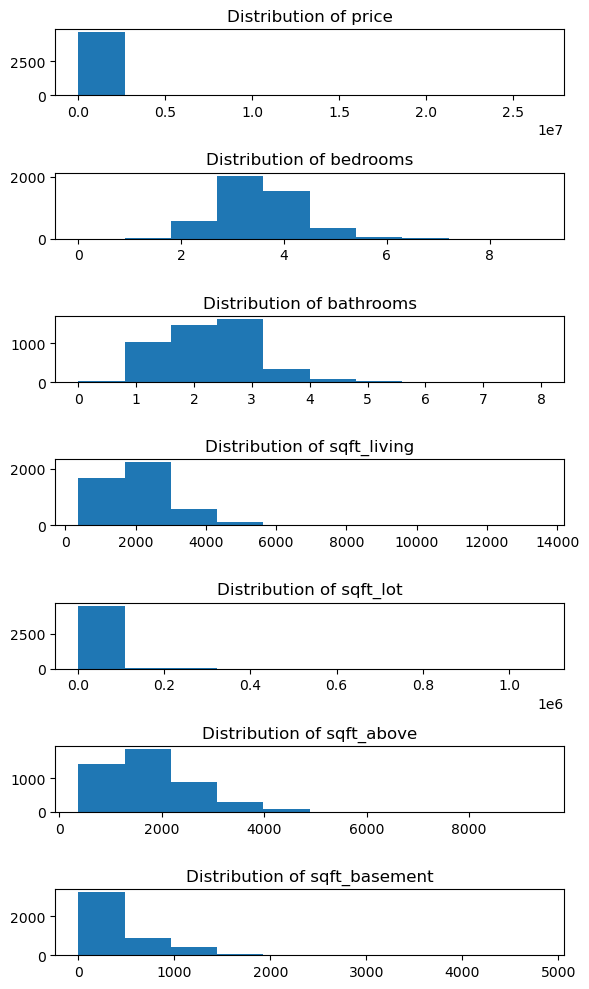

In [9]:
# Check distribution of values in some numerical columns using histograms to further inestigate outliers
num_cols = list(df_summary_stat.columns[1:6])
num_cols.extend(['sqft_above','sqft_basement'])
fig, ax = plt.subplots(len(num_cols), 1, figsize = (6, 10))

for i, col in enumerate(num_cols):
    ax[i].hist(df[col])
    ax[i].set_title(f'Distribution of {col}')
plt.tight_layout()

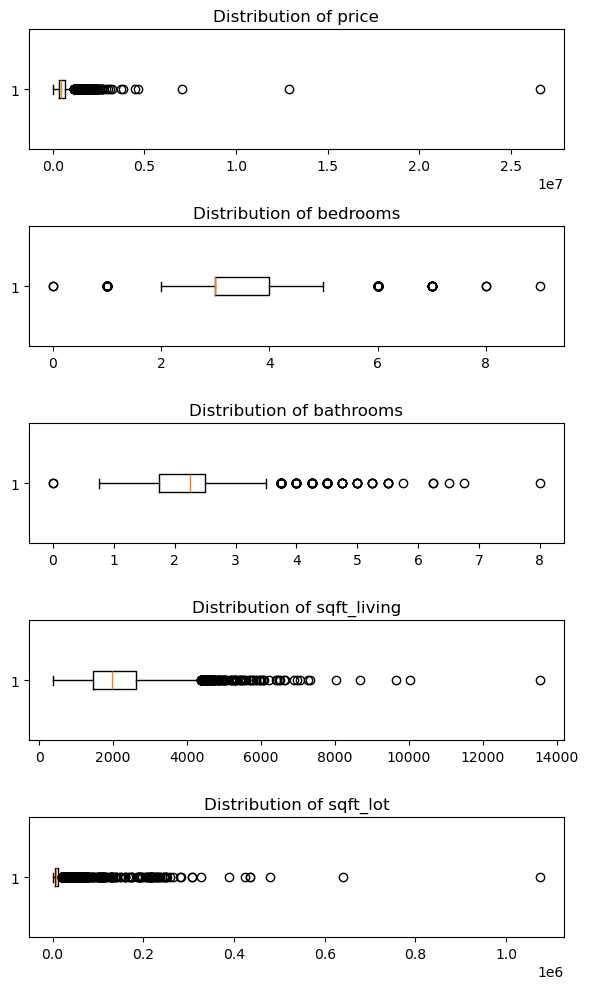

In [10]:
# Check distribution of values in some numerical columns using boxplots
num_cols = df_summary_stat.columns[1:6]
fig, ax = plt.subplots(len(num_cols), 1, figsize = (6, 10))

for i, col in enumerate(num_cols):
    ax[i].boxplot(df[col], vert = False)
    ax[i].set_title(f'Distribution of {col}')
plt.tight_layout()

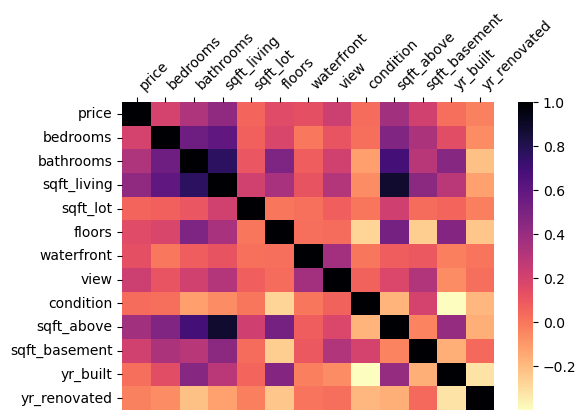

In [11]:
# Check the relationship between numerical variables using a heatmap and correlation
plt.figure(figsize = (6, 4))
ax = sns.heatmap(df.corr(numeric_only  = True), cmap = 'magma_r')
ax.xaxis.tick_top()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left');

# Data Cleaning and Preprocessing

In [12]:
# Function to create years_since_renovation column
def years_since_renovation(row):
    if row['yr_renovated'] == 0:
        return row['year_sold'] - row['yr_built']
    else:
        return row['year_sold'] - row['yr_renovated']


In [13]:
(df['statezip'].str.split(' ', expand = True)).head()

,0,1
0,WA,98133
1,WA,98119
2,WA,98042
3,WA,98008
4,WA,98052


In [14]:
# Remove 0s in price because a house should not cost $0. There are 49 rows (1% of dataset) with that issue
df = df[df['price'] != 0]

# Remove rows where bathroom and bedroom is 0
df = df[(df['bathrooms'] != 0) & (df['bedrooms'] != 0)]
len(df)

# Extract month number from date column to help model to detect seasonality
df['month'] = df['date'].dt.month

# Extract year sold from the date column
df['year_sold'] = df['date'].dt.year

# Create new columns
df['years_since_renovation'] = df.apply(years_since_renovation, axis=1)
df['renovated'] = df['yr_renovated'].apply(lambda x: 0 if x == 0 else 1)
df['house_age'] = df['year_sold'] - df['yr_built']
df['has_basement'] = df['sqft_basement'].apply(lambda x: 0 if x == 0 else 1)
df[['state', 'zipcode']] = df['statezip'].str.split(' ', expand = True)

# Drop irrelevant columns
df = df.drop(columns = ['date', 'year_sold', 'yr_built', 'yr_renovated', 'street', \
                        'country', 'sqft_basement', 'sqft_above', 'statezip', 'state'])
df.head()


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,city,month,years_since_renovation,renovated,house_age,has_basement,zipcode
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,Shoreline,5,9,1,59,0,98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,Seattle,5,93,0,93,1,98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,Kent,5,48,0,48,0,98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,Bellevue,5,51,0,51,1,98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,Redmond,5,22,1,38,1,98052


In [15]:
# Split data to feature matrix and target vector
X = df.drop(columns = ['price'])
y = df['price']

In [16]:
print(X.head())
y.head()

   bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0       3.0       1.50         1340      7912     1.5           0     0   
1       5.0       2.50         3650      9050     2.0           0     4   
2       3.0       2.00         1930     11947     1.0           0     0   
3       3.0       2.25         2000      8030     1.0           0     0   
4       4.0       2.50         1940     10500     1.0           0     0   

   condition       city  month  years_since_renovation  renovated  house_age  \
0          3  Shoreline      5                       9          1         59   
1          5    Seattle      5                      93          0         93   
2          4       Kent      5                      48          0         48   
3          4   Bellevue      5                      51          0         51   
4          4    Redmond      5                      22          1         38   

   has_basement zipcode  
0             0   98133  
1             1 

0     313000.0
1    2384000.0
2     342000.0
3     420000.0
4     550000.0
Name: price, dtype: float64

In [5]:
# OneHotEncode city column
cat_col = ['city']
onehot = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
transformer = ColumnTransformer([
    ('onehot', onehot, cat_col)
], remainder = 'passthrough')

# Output a dataframe
transformer.set_output(transform="pandas")

transformed_X = transformer.fit_transform(X)
transformed_X

In [8]:
# Train-test split
# Set random seed for reproducibility
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size = 0.3)

# Log transform target
# Log function
def log_func(x):
    # Using np.log1p for numerical stability
    return np.log1p(x)

# Inverse function
def exp_func(x):
    # Using np.expm1 as the inverse of np.log1p
    return np.expm1(x)

# Instatiate  RandomForest model
regressor = RandomForestRegressor()

# Log transform the target
rfmodel = TransformedTargetRegressor(
    regressor=regressor,
    func=log_func,
    inverse_func=exp_func
)

rfmodel.fit(X_train, y_train)
y_pred = rfmodel.predict(X_test)
y_pred[:10]

In [13]:
# Function to evaluate model
def evaluate(y_test, y_pred):
    ''' This function takes y_test and y_pred evaluate the model using different metrics'''
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    performance = {
        'Mean Absolute Error' : round(mae),
        'Root Mean Squared Error' : round(rmse),
        'R2 Score' : round(r2, 2)
    }

    return performance

In [20]:
rfscores = evaluate(y_test, y_pred)
rfscores

{'Mean Absolute Error': 108361,
 'Root Mean Squared Error': 206035,
 'R2 Score': 0.69}

In [21]:
# Instatiate  LinearRegression model

regressor = LinearRegression()

# Log transform the target
lrmodel = TransformedTargetRegressor(
    regressor=regressor,
    func=log_func,
    inverse_func=exp_func
)

lrmodel.fit(X_train, y_train)
y_pred = lrmodel.predict(X_test)
y_pred[:10]

array([1606315.67524041,  479606.8685101 ,  514022.18382136,
        486998.57296182,  545190.84857811,  461052.62539018,
        392963.51740731,  322856.10281934,  509080.56609884,
        640802.82148506])

In [22]:
lrscores = evaluate(y_test, y_pred)
lrscores

{'Mean Absolute Error': 139000,
 'Root Mean Squared Error': 937626,
 'R2 Score': -5.39}

# Tuning Hperparameters to Improve Model Performance

In [23]:
# First use RandomizedSearchCV to find the best parameters
# Instatiate  RandomForest model
np.random.seed(42)

regressor = RandomForestRegressor()

# Log transform the target
model = TransformedTargetRegressor(
    regressor=regressor,
    func=log_func,
    inverse_func=exp_func
)

param_grid = {
    'regressor__n_estimators': [100, 200, 500, 1000],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10, 20],
    'regressor__min_samples_leaf': [1, 2, 4, 8],
    'regressor__max_features': ['sqrt', 'log2', 0.5, None]
}

rfmodel2 = RandomizedSearchCV(estimator = model, param_distributions = param_grid, n_jobs = -1, cv = 5, verbose = 2)


rfmodel2.fit(X_train, y_train)


In [24]:
rfmodel2.best_params_

In [25]:
y_pred = rfmodel2.predict(X_test)
rfmodel2_score = evaluate(y_test, y_pred)
rfmodel2_score

In [26]:
grid = {
    'regressor__n_estimators': [800, 1000, 1200],
    'regressor__min_samples_split': [2, 5, 8],
    'regressor__min_samples_leaf': [1, 2, 3],
    'regressor__max_features': ['log2', 'sqrt'],
    'regressor__max_depth': [None, 20, 40]
}

rfmodel3 = GridSearchCV(estimator = model, param_grid = grid, n_jobs = -1, cv = None, verbose = 1)


rfmodel3.fit(X_train, y_train)


In [27]:
rfmodel3.best_params_
# result = {'regressor__max_depth': None,
#  'regressor__max_features': 'sqrt',
#  'regressor__min_samples_leaf': 1,
#  'regressor__min_samples_split': 2,
#  'regressor__n_estimators': 800}

In [28]:
y_pred = rfmodel3.predict(X_test)
rfmodel3_score = evaluate(y_test, y_pred)
rfmodel3_score

# Putting it altogether in a  Pipeline for Deployment

In [2]:
# Instatiate a class to pass to the pipeline
class FeatureEngineering(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # Ensure datetime
        X['date'] = pd.to_datetime(X['date'])
        # Extract month and year from the date column
        X['month'] = X['date'].dt.month
        X['year_sold'] = X['date'].dt.year

        # Feature engineering
        X['house_age'] = X['year_sold'] - X['yr_built']

        X['years_since_renovation'] = np.where(
            X['yr_renovated'] == 0,
            X['year_sold'] - X['yr_built'],
            X['year_sold'] - X['yr_renovated']
        )

        X['renovated'] = (X['yr_renovated'] != 0).astype(int)

        X['has_basement'] = (X['sqft_basement'] != 0).astype(int)

        X[['state', 'zipcode']] =X['statezip'].str.split(' ', expand = True)


        # Drop unused columns
        X = X.drop(columns=[
            'date','year_sold','yr_built','yr_renovated',
            'street','country','sqft_basement',
            'sqft_above','statezip','state'
        ])

        return X

In [6]:
# Create pipeline
pipeline = Pipeline([
    ("feature_engineering", FeatureEngineering()),
    ("preprocessing", transformer),
    ("model", RandomForestRegressor())
])

In [9]:
# Log transform the target
rfmodel = TransformedTargetRegressor(
    regressor=pipeline,
    func=log_func,
    inverse_func=exp_func
)

In [10]:
# Clean dataset
np.random.seed(42)
df = pd.read_csv('data.csv')
df = df[df['price'] != 0]
df = df[(df['bathrooms'] != 0) & (df['bedrooms'] != 0)]

# Split X and y
X = df.drop(columns='price')
y = df['price']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

# Train model
rfmodel.fit(X_train, y_train)

# Predict
y_pred = rfmodel.predict(X_test)

In [14]:
rfscores = evaluate(y_test, y_pred)
rfscores

{'Mean Absolute Error': 108428,
 'Root Mean Squared Error': 206414,
 'R2 Score': 0.69}

In [12]:
# Save and compress (for upload on GitHub) model
joblib.dump(rfmodel, 'group41.pkl', compress = 3)

['group41.pkl']

In [47]:
# Feature importance
rf = rfmodel.regressor_.named_steps['model']

feature_names = rfmodel.regressor_.named_steps['preprocessing'].get_feature_names_out()

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df

,feature,importance
44,remainder__sqft_living,4.952818e-01
55,remainder__zipcode,8.803620e-02
33,onehot__city_Seattle,5.787872e-02
45,remainder__sqft_lot,5.631978e-02
51,remainder__house_age,5.324837e-02
52,remainder__years_since_renovation,2.516414e-02
43,remainder__bathrooms,2.320364e-02
2,onehot__city_Bellevue,1.711887e-02
49,remainder__condition,1.676185e-02
48,remainder__view,1.438249e-02
